# Robustness Checks


Compact experiments to test stability of the pipeline: target horizon, macro overlay, and feature selection.

## Initial Setup


### Imports and Paths

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from notebooks.params import OUT_DIR
from src.modeling.backtest import BacktestConfig, _summarize_portfolio, backtest_from_scores
from src.modeling.baseline import BaselineConfig, add_momentum_score
from src.modeling.models import (
    ModelIO,
    build_ridge_pipeline,
    build_tree_model,
    fit_predict_oos_scores,
)
from src.modeling.splits import WalkForwardConfig, generate_expanding_walk_forward_splits

STAGES_DIR = Path(OUT_DIR) / "stages"
MODEL_PATH = STAGES_DIR / "panel_model_ready.parquet"

### Load model‑ready panel


In [3]:
df_model = pd.read_parquet(MODEL_PATH)
print("Rows:", len(df_model))


Rows: 10452


### Common config


In [4]:
split_cfg = WalkForwardConfig(train_years=10, test_months=12, embargo_months=3)
splits = list(generate_expanding_walk_forward_splits(df_model, split_cfg))

top_k = 5
bt_cfg = BacktestConfig(top_k=top_k, overlay_enabled=True, stress_threshold=0.5, risk_off_exposure=0.6)

features_all = [c for c in df_model.columns if c not in {
    'date', 'ticker',
    'target_3m', 'target_1m',
    'fwd_ret_1m', 'fwd_ret_3m', 'fwd_ret_6m',
    'macro_regime', 'stress_index', 'slope_10y2y',
}]


### Helper Function

In [5]:
def run_model(target_col, score_col, features, model=None):
    io = ModelIO(target_col=target_col)
    model = model or build_ridge_pipeline(alpha=1.0)
    oos, _ = fit_predict_oos_scores(splits, features, model, io, score_col)
    return oos

## Comparative Robustness

### Base Model and Backtest Results

We use Ridge here because robustness checks require a stable, fast, and interpretable model.
Ridge reduces variance across folds, runs quickly for many experiments, and makes feature‑set effects easier to isolate.
HGB is better for final performance, but less transparent for diagnostics.


In [6]:
# Base model OOS (ridge, 3M, all features) reused across checks
baseline_cfg = BaselineConfig(momentum_col='mom12_pr', score_col='score_baseline_mom')
df_base = add_momentum_score(df_model, baseline_cfg)

oos_base = run_model('target_3m', 'score_ridge', features_all)
oos_base = oos_base.merge(df_base[['date','ticker','score_baseline_mom']], on=['date','ticker'], how='left')
summary_base, artifacts_base = backtest_from_scores(oos_base, {'baseline_mom': 'score_baseline_mom', 'ridge_base': 'score_ridge'}, bt_cfg)

/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: _top_k_by_score(x, score_col, cfg.top_k))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit = data.groupby(date_col).apply(_hit)
/Users/igordragone/projects/hybrid-stock-prediction

### Target 3M vs 1M


We compare model performance when training on 3‑month vs 1‑month targets.
This checks whether the signal is robust to horizon choice.

In [7]:
# target_1m
oos_1m = run_model('target_1m', 'score_ridge_1m', features_all)
oos_1m = oos_1m.merge(df_base[['date','ticker','score_baseline_mom']], on=['date','ticker'], how='left')
summary_1m, artifacts_1m = backtest_from_scores(oos_1m, {'baseline_mom': 'score_baseline_mom', 'ridge_1m': 'score_ridge_1m'}, bt_cfg)

print('Target 3M')
display(summary_base)
print('Target 1M')
display(summary_1m)


Target 3M


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: _top_k_by_score(x, score_col, cfg.top_k))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit = data.groupby(date_col).apply(_hit)
/Users/igordragone/projects/hybrid-stock-prediction

,model,mean_monthly_return,vol_monthly,sharpe,cagr,max_drawdown,mean_turnover,hit_rate
0,baseline_mom,0.021596,0.062418,1.198543,0.264006,-0.253148,0.235088,0.184211
1,ridge_base,0.017175,0.062255,0.955697,0.199350,-0.280271,0.357895,0.189474


Target 1M


,model,mean_monthly_return,vol_monthly,sharpe,cagr,max_drawdown,mean_turnover,hit_rate
0,baseline_mom,0.021596,0.062418,1.198543,0.264006,-0.253148,0.235088,0.184211
1,ridge_1m,0.020131,0.064306,1.084441,0.240393,-0.204662,0.414035,0.203509


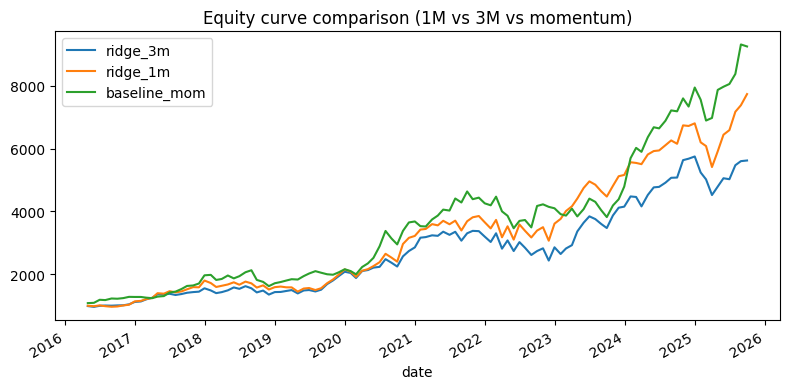

In [8]:
# Equity comparison: Ridge 3M vs Ridge 1M vs Momentum baseline
curves = {
    'ridge_3m': artifacts_base['ridge_base']['equity'],
    'ridge_1m': artifacts_1m['ridge_1m']['equity'],
    'baseline_mom': artifacts_base['baseline_mom']['equity'],
}

plt.figure(figsize=(8, 4))
for name, eq in curves.items():
    (eq * 1000).plot(label=name)
plt.title('Equity curve comparison (1M vs 3M vs momentum)')
plt.legend()
plt.tight_layout()


The 1M target aligns with monthly rebalancing, so it tends to track the equity curve more closely than the 3M target.
Momentum remains strong as a simple rule, which is expected in trend‑driven markets, but Ridge 1M closes part of the gap versus Ridge 3M.


### Macro overlay on/off

We keep the model unchanged and toggle the risk‑off overlay to see its impact on portfolio performance.


In [9]:
oos = oos_base.copy()

bt_on = BacktestConfig(top_k=top_k, overlay_enabled=True, stress_threshold=0.5, risk_off_exposure=0.6)
bt_off = BacktestConfig(top_k=top_k, overlay_enabled=False)

summary_on = summary_base[summary_base['model'] == 'ridge_base'].copy()
summary_on = summary_on.assign(overlay='on')
summary_off, artifacts_off = backtest_from_scores(oos, {'ridge_off': 'score_ridge'}, bt_off)
summary_off = summary_off.assign(overlay='off')

summary_overlay = pd.concat([summary_on, summary_off])
display(summary_overlay)


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: _top_k_by_score(x, score_col, cfg.top_k))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit = data.groupby(date_col).apply(_hit)


,model,mean_monthly_return,vol_monthly,sharpe,cagr,max_drawdown,mean_turnover,hit_rate,overlay
1,ridge_base,0.017175,0.062255,0.955697,0.199350,-0.280271,0.357895,0.189474,on
0,ridge_off,0.019020,0.065378,1.007810,0.223226,-0.265452,0.357895,0.189474,off


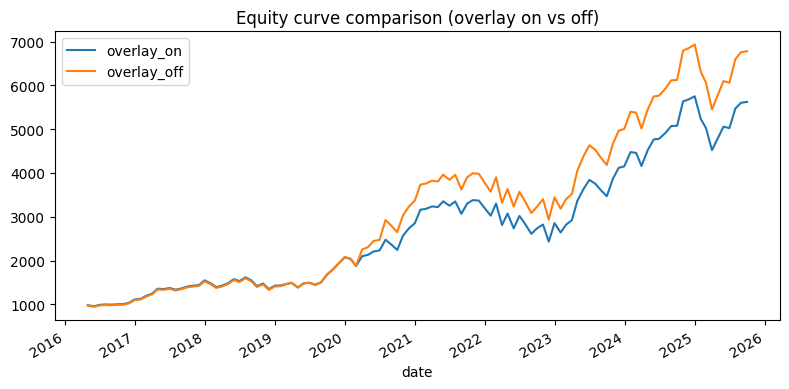

In [10]:
# Equity curve: overlay on vs off
curves = {
    'overlay_on': artifacts_base['ridge_base']['equity'],
    'overlay_off': artifacts_off['ridge_off']['equity'],
}
plt.figure(figsize=(8, 4))
for name, eq in curves.items():
    (eq * 1000).plot(label=name)
plt.title('Equity curve comparison (overlay on vs off)')
plt.legend()
plt.tight_layout()


The overlay‑off curve is higher because full exposure captures more upside in calm periods.
The overlay‑on version trades return for risk control by cutting exposure in stress regimes, which lowers CAGR but can reduce drawdowns.


### Feature selection (funds‑only vs techs‑only)

We evaluate fundamentals‑only, technicals‑only, and the full feature set to assess feature group contribution.

In [11]:
fund_cols = [c for c in features_all if c.endswith('_pr') and any(k in c for k in ['roe','roa','margin','growth','debt','coverage','turnover','fcf','delta'])]
tech_cols = [c for c in features_all if c in ['mom12_pr','mom6_pr','mom3_pr','trend_ratio_pr','vol_pr','vol_ratio_pr']]

# funds only
oos_fund = run_model('target_3m', 'score_fund', fund_cols)
summary_fund, artifacts_fund = backtest_from_scores(oos_fund, {'funds_only': 'score_fund'}, bt_cfg)

# tech only
oos_tech = run_model('target_3m', 'score_tech', tech_cols)
summary_tech, artifacts_tech = backtest_from_scores(oos_tech, {'tech_only': 'score_tech'}, bt_cfg)

# both (reuse base model)
summary_all = summary_base[summary_base['model'] == 'ridge_base'].copy()
summary_all['model'] = 'all_features'
artifacts_all = {'all_features': artifacts_base['ridge_base']}

summary_ft = pd.concat([summary_fund, summary_tech, summary_all])
display(summary_ft)


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: _top_k_by_score(x, score_col, cfg.top_k))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/backtest.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit = data.groupby(date_col).apply(_hit)
/Users/igordragone/projects/hybrid-stock-prediction

,model,mean_monthly_return,vol_monthly,sharpe,cagr,max_drawdown,mean_turnover,hit_rate
0,funds_only,0.016898,0.050162,1.166906,0.205276,-0.187881,0.226316,0.173684
0,tech_only,0.018432,0.072949,0.875273,0.208127,-0.303577,0.478947,0.191228
1,all_features,0.017175,0.062255,0.955697,0.199350,-0.280271,0.357895,0.189474


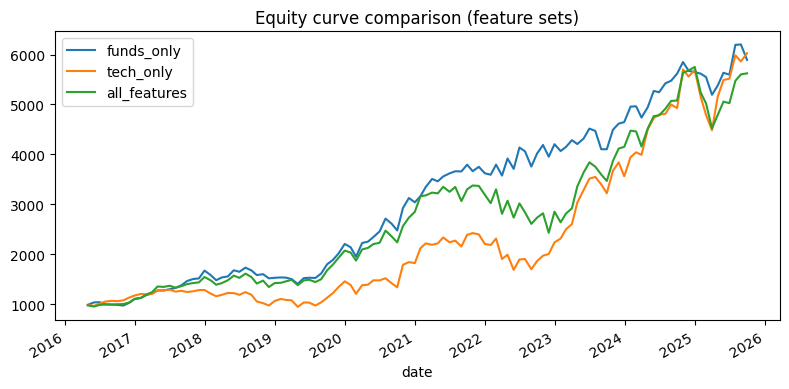

In [12]:
# Equity curve: funds vs tech vs all features
curves = {
    'funds_only': artifacts_fund['funds_only']['equity'],
    'tech_only': artifacts_tech['tech_only']['equity'],
    'all_features': artifacts_all['all_features']['equity'],
}
plt.figure(figsize=(8, 4))
for name, eq in curves.items():
    (eq * 1000).plot(label=name)
plt.title('Equity curve comparison (feature sets)')
plt.legend()
plt.tight_layout()


Funds‑only is steadier with lower volatility, while tech‑only is more cyclical and volatile; this matches their economic intuition.
Combining all features sits in between, capturing diversification benefits but diluting the strongest single‑category signals.


### Benchmark: S&P 500

In [ ]:
BENCH_PATH = Path(OUT_DIR) / 'benchmarks' / 'sp500.parquet'

if BENCH_PATH.exists():
    sp = pd.read_parquet(BENCH_PATH)
    sp['date'] = pd.to_datetime(sp['date'])
    if 'ret_1m' not in sp.columns and 'close' in sp.columns:
        sp = sp.sort_values('date')
        sp['ret_1m'] = sp['close'].pct_change(1)
    if 'equity' not in sp.columns and 'ret_1m' in sp.columns:
        sp = sp.dropna(subset=['ret_1m'])
        sp['equity'] = (1 + sp['ret_1m']).cumprod()
    display(sp[['date', 'ret_1m', 'equity']].tail(5))
else:
    # Fetch SPY from Yahoo Finance for the dataset date range
    start_date = pd.to_datetime(df_model['date']).min().strftime('%Y-%m-%d')
    end_date = pd.to_datetime(df_model['date']).max().strftime('%Y-%m-%d')
    spy = yf.download('SPY', start=start_date, end=end_date, auto_adjust=True, progress=False)
    if spy.empty:
        print('SPY download failed. Check network or ticker.')
    else:
        if isinstance(spy.columns, pd.MultiIndex):
            spy.columns = [c[0] for c in spy.columns]
        spy = spy.reset_index()
        spy.columns = [c.lower() for c in spy.columns]
        close_col = 'close' if 'close' in spy.columns else 'adj close'
        if close_col not in spy.columns:
            raise ValueError(f'No close column found in SPY data: {spy.columns.tolist()}')
        
        spy = spy.rename(columns={close_col: 'close'})
        spy['date'] = pd.to_datetime(spy['date'])
        monthly = spy.set_index('date').resample('M')['close'].last().reset_index()
        monthly['ret_1m'] = monthly['close'].pct_change(1)
        monthly = monthly.dropna(subset=['ret_1m'])
        monthly['equity'] = (1 + monthly['ret_1m']).cumprod()
        
        BENCH_PATH.parent.mkdir(parents=True, exist_ok=True)
        monthly.to_parquet(BENCH_PATH, index=False)
        
        display(monthly[['date', 'ret_1m', 'equity']].tail(5))

,date,ret_1m,equity
231,2025-05-31,0.062845,6.638620
232,2025-06-30,0.051386,6.979754
233,2025-07-31,0.023032,7.140508
234,2025-08-31,0.020520,7.287028
235,2025-09-30,0.031734,7.518275


/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/1850290996.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = spy.set_index('date').resample('M')['close'].last().reset_index()


,model,mean_monthly_return,vol_monthly,sharpe,cagr,max_drawdown,mean_turnover,hit_rate
0,baseline_mom,0.021596,0.062418,1.198543,0.264006,-0.253148,0.235088,0.184211
1,ridge_base,0.017175,0.062255,0.955697,0.199350,-0.280271,0.357895,0.189474
2,sp500,0.012692,0.043919,1.001082,0.150223,-0.239272,NaN,NaN


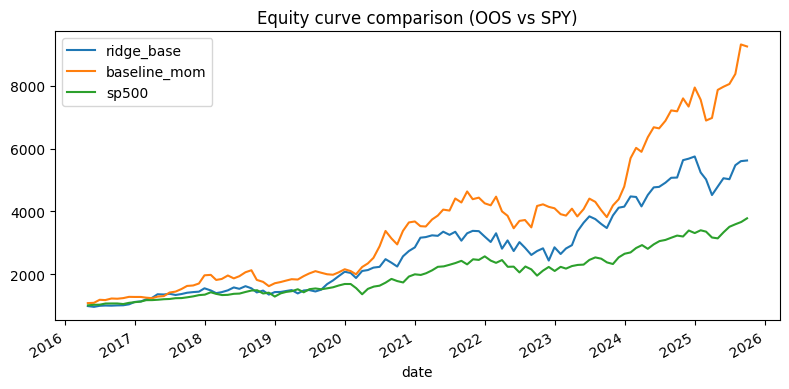

In [18]:
# Compare SPY vs model equity/metrics on OOS window
spy = pd.read_parquet(BENCH_PATH)
spy['date'] = pd.to_datetime(spy['date'])

# Build a clean monthly series first
if 'close' not in spy.columns:
    raise ValueError('SPY data missing close column; re-download benchmark.')
monthly = spy.set_index('date').resample('M')['close'].last().reset_index()
monthly['ret_1m'] = monthly['close'].pct_change(1)
monthly = monthly.dropna(subset=['ret_1m'])
monthly['month'] = monthly['date'].dt.to_period('M')

# Align to OOS months
oos_months = pd.Series(oos_base['date']).dt.to_period('M').drop_duplicates()
spy_oos = monthly[monthly['month'].isin(oos_months)].copy()

if spy_oos.empty:
    print('SPY OOS alignment is empty; check benchmark date range.')

spy_oos = spy_oos.sort_values('date')
spy_oos['equity'] = (1 + spy_oos['ret_1m']).cumprod()

# Metrics for SPY
spy_summary = _summarize_portfolio(spy_oos.set_index('date')['ret_1m'])
spy_row = pd.DataFrame([{'model': 'sp500', **spy_summary, 'hit_rate': np.nan}])

# Compare metrics (ridge vs baseline vs SPY)
summary_compare = pd.concat([summary_base[['model','mean_monthly_return','vol_monthly','sharpe','cagr','max_drawdown','mean_turnover','hit_rate']], spy_row], ignore_index=True)
display(summary_compare)

# Equity curve comparison (models + SPY)
curves = {
    'ridge_base': artifacts_base['ridge_base']['equity'],
    'baseline_mom': artifacts_base['baseline_mom']['equity'],
    'sp500': spy_oos.set_index('date')['equity'],
}
plt.figure(figsize=(8, 4))
for name, eq in curves.items():
    (eq * 1000).plot(label=name)
plt.title('Equity curve comparison (OOS vs SPY)')
plt.legend()
plt.tight_layout()


SP500 shows lower return and volatility, which is consistent with a broad benchmark over 2016–2025.
Momentum outperforms in this period, while Ridge sits between SPY and the rule‑based baseline, matching the equity curve ordering.


## Interpretability & Stability

### Feature importance (Ridge vs HGB)


We show the most influential features for the linear model (absolute coefficients) and the tree model (feature importances).
This is a compact interpretability check, not an exhaustive analysis.

asset_turnover_pr       0.012979
vol_pr                 -0.012003
interest_coverage_pr   -0.006421
mom12_pr               -0.006249
trend_ratio_pr          0.005694
fcf_assets_pr           0.005490
roe_pr                 -0.004697
revenue_growth_pr       0.003550
mom6_pr                 0.002984
roa_pr                 -0.002977
gross_margin_pr         0.002845
operating_margin_pr     0.002789
mom3_pr                -0.002726
delta_roe_pr            0.002242
earnings_growth_pr     -0.001502
dtype: float64

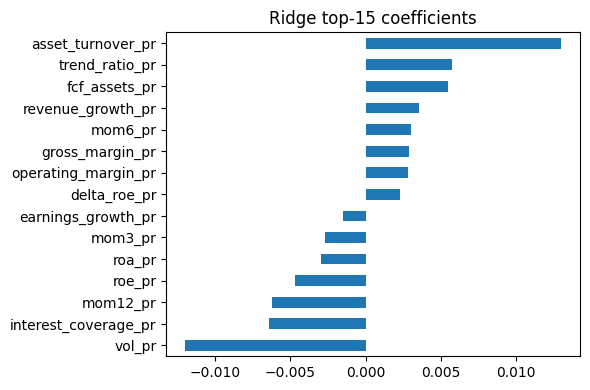

In [13]:
X = df_model[features_all]
y = df_model['target_3m']

ridge = build_ridge_pipeline(alpha=1.0)
ridge.fit(X, y)
ridge_coef = pd.Series(ridge.named_steps['reg'].coef_, index=features_all)
ridge_coef = ridge_coef.reindex(ridge_coef.abs().sort_values(ascending=False).index)
display(ridge_coef.head(15))

# HGB does not expose native feature_importances_; Ridge coefficients are used here for interpretability.
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ridge_coef.head(15).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Ridge top‑15 coefficients')
plt.tight_layout()


Ridge highlights a mix of profitability/quality (margins, ROE/ROA), balance‑sheet stability (interest coverage), and trend signals (mom/trend).
Negative coefficients on volatility and some momentum horizons suggest the model penalizes excessive risk or late‑cycle spikes, while stronger positive weights favor efficient, improving fundamentals.


vol_pr                  0.029139
trend_ratio_pr          0.020659
asset_turnover_pr       0.018106
mom6_pr                 0.014249
revenue_growth_pr       0.012053
mom12_pr                0.009599
interest_coverage_pr    0.006025
delta_roe_pr            0.005835
debt_pr                 0.005610
operating_margin_pr     0.005225
roe_pr                  0.002212
fcf_assets_pr           0.001909
roa_pr                  0.001620
vol_ratio_pr            0.001478
earnings_growth_pr      0.001120
dtype: float64

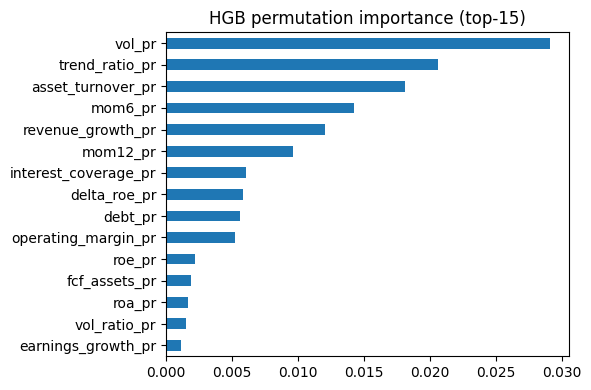

In [14]:
# Permutation importance for HGB (model-agnostic)
from sklearn.inspection import permutation_importance

hgb = build_tree_model()
hgb.fit(X, y)
perm = permutation_importance(hgb, X, y, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=features_all).sort_values(ascending=False)
display(perm_imp.head(15))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
perm_imp.head(15).sort_values().plot(kind='barh', ax=ax)
ax.set_title('HGB permutation importance (top‑15)')
plt.tight_layout()


HGB’s permutation importance emphasizes volatility and trend features, suggesting the non‑linear model leans more on technical regime signals.
Fundamental features still appear, but with smaller marginal impact compared to the strongest technical drivers.


### Temporal Stability


We track the stability of the Information Coefficient over time using a 12‑month rolling window.
Stable, positive IC suggests the signal is persistent; high volatility suggests fragility.

/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/2752796899.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(_ic)
/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/2752796899.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(_ic)
/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/2752796899.py:6: FutureWa

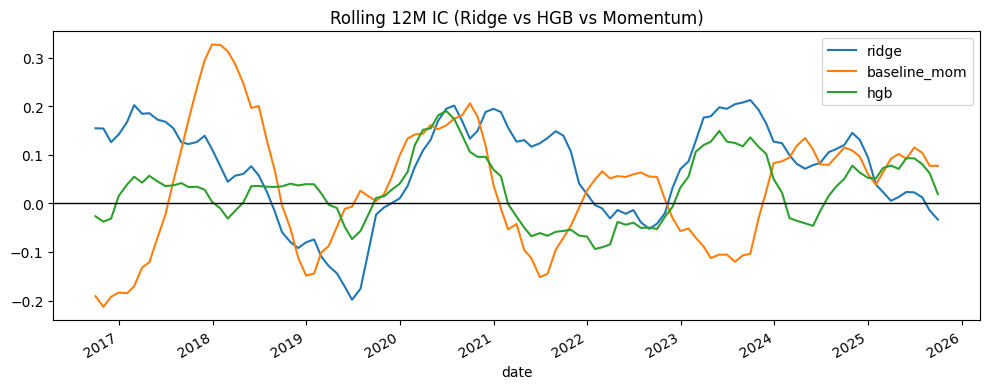

In [15]:
def monthly_ic(df, score_col, ret_col):
    def _ic(x):
        if x[score_col].nunique() < 2 or x[ret_col].nunique() < 2:
            return np.nan
        return x[[score_col, ret_col]].corr(method='spearman').iloc[0, 1]
    return df.groupby('date').apply(_ic)

# Ridge (base)
ic_ridge = monthly_ic(oos_base, 'score_ridge', 'fwd_ret_3m').rolling(12, min_periods=6).mean()
# Momentum baseline (same OOS window)
ic_mom = monthly_ic(oos_base, 'score_baseline_mom', 'fwd_ret_3m').rolling(12, min_periods=6).mean()
# HGB (fit once for diagnostics)
oos_hgb = run_model('target_3m', 'score_hgb', features_all, model=build_tree_model())
ic_hgb = monthly_ic(oos_hgb, 'score_hgb', 'fwd_ret_3m').rolling(12, min_periods=6).mean()

plt.figure(figsize=(10, 4))
ic_ridge.plot(label='ridge')
ic_mom.plot(label='baseline_mom')
ic_hgb.plot(label='hgb')
plt.axhline(0, color='black', linewidth=1)
plt.title('Rolling 12M IC (Ridge vs HGB vs Momentum)')
plt.legend()
plt.tight_layout()


Across the sample, momentum shows strong early peaks but also sharp drawdowns, while Ridge is steadier with fewer extreme swings.
HGB sits in between: it captures non‑linear regimes but still exhibits periods of negative IC, confirming that signal strength is time‑varying for all models.


## Macro Regimes Analysis

### Mean return by macro regime

/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/2872918305.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_ret = base.groupby('macro_regime')['fwd_ret_1m'].mean().sort_values()


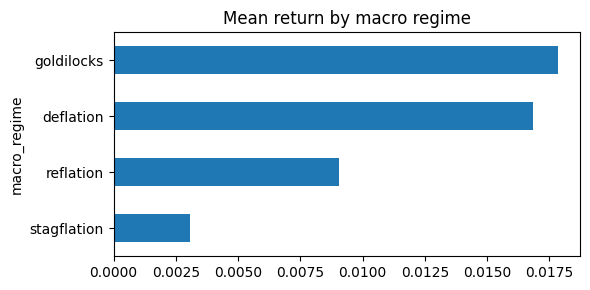

In [35]:
# Mean return by macro regime (model-ready panel)
macro_cols = ['date', 'ticker', 'macro_regime', 'fwd_ret_1m', 'sector']
base = df_model[[c for c in macro_cols if c in df_model.columns]].dropna(subset=['macro_regime'])

# If sector missing, merge from a stage that contains it
if 'sector' not in base.columns:
    sector_path = STAGES_DIR / 'panel_features.parquet'
    if sector_path.exists():
        sector_df = pd.read_parquet(sector_path, columns=['date','ticker','sector'])
        base = base.merge(sector_df, on=['date','ticker'], how='left')

# Mean return by macro regime
if 'fwd_ret_1m' in base.columns:
    regime_ret = base.groupby('macro_regime')['fwd_ret_1m'].mean().sort_values()
    plt.figure(figsize=(6, 3))
    regime_ret.plot(kind='barh')
    plt.title('Mean return by macro regime')
    plt.tight_layout()
else:
    print('fwd_ret_1m not found; cannot compute regime returns')

These averages are plausible: Goldilocks tends to deliver the strongest broad returns, while stagflation is typically the weakest regime.
Deflation and reflation sit in between, reflecting mixed growth/inflation dynamics and more volatile risk appetite.


### Sector strength by macro regime

In [33]:
# Sector strength by macro regime
if {'macro_regime','sector','fwd_ret_1m'}.issubset(base.columns):
    pivot = (
        base.groupby(['macro_regime','sector'])['fwd_ret_1m']
            .mean()
            .unstack('sector')
            .sort_index()
    )
    display(pivot)
else:
    print('Missing macro_regime/sector/fwd_ret_1m for sector-by-regime table')

/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/1990162690.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  base.groupby(['macro_regime','sector'])['fwd_ret_1m']


sector,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Real Estate,Technology,Utilities
macro_regime,,,,,,,,,
deflation,0.021906,0.009050,0.006336,0.026782,0.007735,0.018602,0.019895,0.030268,0.011725
goldilocks,0.027623,0.012241,0.016233,0.018050,0.012487,0.022637,0.009733,0.030697,0.011538
reflation,0.009650,0.010006,0.013242,0.001758,0.011762,0.002841,0.015060,0.008901,0.008531
stagflation,0.024856,0.007814,-0.014834,-0.008868,0.005507,-0.005649,-0.008781,0.029135,0.000960


The sector‑by‑regime pivot shows which sectors tend to lead or lag within each regime.

/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/2536664531.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  base.groupby(['macro_regime','sector'])['fwd_ret_1m']


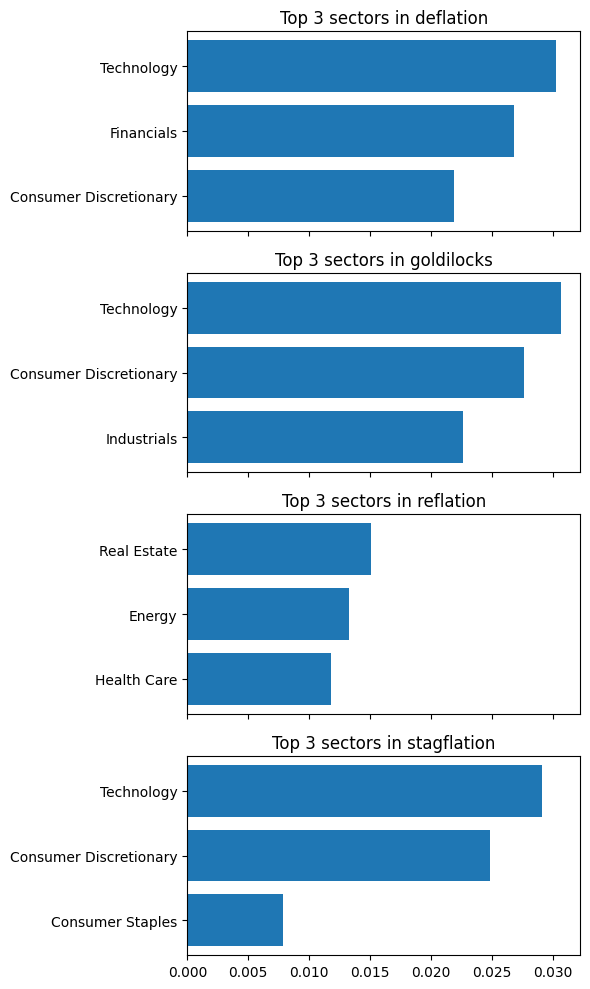

In [32]:
# Plot top-3 sectors per regime
if {'macro_regime','sector','fwd_ret_1m'}.issubset(base.columns):
    top3 = (
        base.groupby(['macro_regime','sector'])['fwd_ret_1m']
            .mean()
            .reset_index()
    )
    regimes = top3['macro_regime'].unique()
    n = len(regimes)
    fig, axes = plt.subplots(n, 1, figsize=(6, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, regime in zip(axes, regimes):
        subset = top3[top3['macro_regime'] == regime].sort_values('fwd_ret_1m', ascending=False).head(3)
        ax.barh(subset['sector'], subset['fwd_ret_1m'])
        ax.set_title(f'Top 3 sectors in {regime}')
        ax.invert_yaxis()
    plt.tight_layout()
else:
    print('Missing macro_regime/sector/fwd_ret_1m for sector-by-regime plot')


Note: these rankings are simple mean returns by regime (not risk‑adjusted) and can be sensitive to regime duration and sample size.
Use them as descriptive context rather than causal evidence.


## Top-K Analysis

### Top‑K frequency by ticker and sector

We count how often each ticker/sector appears in the monthly top‑K for each model.

In [ ]:
def topk_frequency(df, score_col, k):
    topk = (
        df.dropna(subset=[score_col])
          .groupby('date', group_keys=False)
          .apply(lambda x: x.nlargest(k, score_col))
    )
    return topk

# Build a sector map if missing
sector_map = None
if 'sector' in df_model.columns:
    sector_map = df_model[['date','ticker','sector']].copy()
else:
    sector_path = STAGES_DIR / 'panel_features.parquet'
    if sector_path.exists():
        sector_map = pd.read_parquet(sector_path, columns=['date','ticker','sector'])

models = {
    'ridge_base': (oos_base, 'score_ridge'),
    'baseline_mom': (oos_base, 'score_baseline_mom'),
}
if 'oos_hgb' in globals():
    models['hgb'] = (oos_hgb, 'score_hgb')

for name, (df_scores, score_col) in models.items():
    print(f'—----------- {name} —-----------')
    topk = topk_frequency(df_scores, score_col, top_k)
    # ticker frequency
    ticker_freq = topk['ticker'].value_counts().head(10)
    display(pd.DataFrame({'ticker': ticker_freq.index, 'topk_months': ticker_freq.values}).set_index('ticker'))
    # sector frequency
    if sector_map is not None:
        topk_sec = topk.merge(sector_map, on=['date','ticker'], how='left')
        sec_freq = topk_sec['sector'].value_counts().head(10)
        display(pd.DataFrame({'sector': sec_freq.index, 'topk_months': sec_freq.values}).set_index('sector'))
    else:
        print('Sector map not available for', name)
    
    print('—-----------—-----------—-----------')


—----------- ridge_base —-----------


/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/1569771227.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(k, score_col))


,topk_months
ticker,
TSLA,77
AMZN,63
NVDA,55
META,49
SBUX,32
UNH,32
NKE,27
SHEL,27
ABBV,26


,topk_months
sector,
Consumer Discretionary,199
Technology,138
Energy,77
Health Care,72
Industrials,34
Consumer Staples,29
Real Estate,18
Financials,3


—-----------—-----------—-----------
—----------- baseline_mom —-----------


...

—-----------—-----------—-----------
—----------- hgb —-----------


/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_19115/1569771227.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(k, score_col))


,topk_months
ticker,
TSLA,91
NVDA,73
BA,62
META,37
COP,31
AMZN,28
COST,25
BAC,20
SBUX,18


,topk_months
sector,
Consumer Discretionary,153
Technology,141
Industrials,86
Energy,63
Consumer Staples,38
Health Care,32
Financials,29
Real Estate,19
Utilities,9


—-----------—-----------—-----------


These frequencies are plausible: high‑momentum growth names (e.g., TSLA/NVDA/AMZN) and Tech/Consumer Discretionary dominate top‑K counts across models.
Differences by model are expected: Ridge and HGB emphasize similar growth sectors, while the momentum baseline leans even more into recent winners and cyclical sectors.
